In [1]:
import pickle
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
sys.path.insert(0, './src')


from discipline_stats import (
    TestResults,
    filter_league_season,
    compare_two_groups,
    compare_mean_to_threshold,
    team_summary,
    venue_summary,
    plot_distribution,
    plot_home_away_distribution,
    plot_league_bar,
    plot_forest,
    check_normality,
    test_home_away,
    test_team_vs_rest,
    test_all_teams,
    compare_two_teams,
)

with open('./data/processed/team_matches.pkl', 'rb') as f:
    team_matches = pickle.load(f)

with open('./data/raw/european_leagues_data.pkl', 'rb') as f:
    all_matches = pickle.load(f)

print('Import successful')
print(f'team_matches shape: {team_matches.shape}')

Import successful
team_matches shape: (53386, 20)


In [3]:
def get_outliers(df, col):
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    mask = (df[col] < lower) | (df[col] > upper)
    outlier_df = df[mask].copy()
    outlier_arr = outlier_df[col].to_numpy()

    return outlier_df, outlier_arr

In [4]:
# Leagues Dataset

df_serie_a = all_matches['Serie_A']
df_premier_league = all_matches['Premier_League']
df_la_liga = all_matches['La_Liga']
df_bundesliga = all_matches['Bundesliga']

# Latest year dataset

ita_2526 = df_serie_a[df_serie_a['season'] == '2526']
eng_2526 = df_premier_league[df_premier_league['season'] == '2526']
esp_2526 = df_la_liga[df_la_liga['season'] == '2526']
ger_2526 = df_bundesliga[df_bundesliga['season'] == '2526']

In [5]:
# all matches dataset for Serie A and Premier League season 24-25

all_matches_serie_a_2425 = filter_league_season(all_matches['Serie_A'], None, '2425')
all_matches_premier_league_2425 = filter_league_season(all_matches['Premier_League'], None, '2425')

all_matches_serie_a_2425['total_fouls'] = all_matches_serie_a_2425['HF'] + all_matches_serie_a_2425['AF']
all_matches_premier_league_2425['total_fouls'] = all_matches_premier_league_2425['HF'] + all_matches_premier_league_2425['AF']

# L'Inter e gli Outlier

## Premessa

Questo notebook sara' pieno di premesse, mani avanti e tanti tentativi di spiegare, in maniera intuitiva, concetti che stanno entrando nel lessico comune ma che spesso possono procurare fraintendimenti su come si interpretano. 

La premessa piu' importante, per quanto mi riguarda, parte da un fatto personale. Ho un Dottorato di Ricerca in Scienze Computazionali e Informatiche e la mia tesi di dottorato non sarebbe stata mai scritta se non ci fosse stato l'aiuto determinante del Professore Bruno Siciliano e del suo Prisma Lab. Spesso non riconosciamo i colpi di fortuna che ci capitano nella vita, uno di questi e' stata la possibilita' di poter conoscere il professor Siciliano e, per un breve periodo, addirittura aver collaborato con il suo gruppo. 

Detto questo, quando qualcuno tira in ballo i fatti citando numeri e statistiche, mi incuriosisco e cerco di capire su quali fatti si possano basare alcune affermazioni. E vista la stima e riconoscenza che ho verso il professor Siciliano, sono stato attirato da un titolo della testata tuttonapoli.net che citava ["Prof. Siciliano: "5 punti recuperati all'Inter, ma c'e' un rimpianto. E' stato uno scandalo!"](https://www.tuttonapoli.net/radio-tutto-napoli/prof-siciliano-5-punti-recuperati-all-inter-ma-c-e-un-rimpianto-e-stato-uno-scandalo-639256). Riporto dall'articolo una frase:

> **Ci sono anche dati statistici su questo tema?** 
> "Si, le statistiche dicono che l'Inter e' la squadra con meno cartellini gialli e 
> meno cartellini rossi. 
> La statistica piu' interessante e' il rapporto tra numero di falli fatti 
> e cartellini distribuiti: 
> mentre il valore medio e' un cartellino ogni quattro falli, 
> l'Inter prende un cartellino giallo ogni otto falli e mezzo. I numeri non mentono".

Ascoltando poi il podcast, il professor Siciliano cita anche che il dato sarebbe un "outlier".  A questo punto, la mia coda di avvocato del diavolo ha iniziato a scodinzolare (si, sono un diavolo avvocato del diavolo. Ad alcuni di noi diavoli e' stata data la possibilita' di scegliere tra le corna e la coda, e ho pensato che la coda fosse piu' facile da nascondere e potesse anche essere piu' utile in alcune situazioni) e mi sono messo alla ricerca dei dati che potessero confermare l'affermazione del professore.

Quando si fa un'analisi dati e si studia un'affermazione, prima di tutto si parte dall'affermazione stessa. Sia il podcast che il testo riportato non sono univocamente precisi, come ci si aspetta da un'intervista che ha carattere generale e non specifico, e quando si parla di falli fatti e cartellini distribuiti non e' univoco ma almeno abbiamo un punto di partenza: ***"l'Inter prende un cartellino giallo ogni otto falli e mezzo mentre il valore medio e' un cartellino ogni quattro falli"***. 

Dato che a me piace partire facile, allora mi sono concentrato su uno studio abbastanza semplice: il rapporto tra cartellini ricevuti e falli fatti. "Partire facile" e' sempre relativo, dato che anche un obiettivo che sembra lineare e semplice porta alcuni caveat. Nell'analisi dati, o Data Science, vige la regola zero che e' "garbage in, garbage out": se si fa un'analisi con dati che non sono buoni o non ben definiti, il risultato sara' spazzatura. Aggiungo che spesso le analisi dei dati, i modelli che si introducono, amplificano il risultato e anche dei dati parzialmente sbagliati o non attinenti, possono venire amplificati nelle conclusioni che risulteranno quindi piu' simili a una discarica che a un bidone dell'immondizia.

E a questo punto, c'e' un'altra premessa e mi piace chiarirla dall'inizio. Il vero scopo di questo notebook non e' dare ragione al Professor Siciliano o meno, ma di propormi come il Barbero dell'Analisi Dati, ossia quello che, con fare bonaccione, ti spiega le cose facendoti appassionare su di un argomento del quale, 10 minuti prima, non ti interessava per nulla, tipo la forma delle maniglie nella Firenze dei Medici, e dopo averlo ascoltato ti metti il monocolo e cambi tutte le porte di casa. Ma, a differenza di Barbero, io parlero' di concetti matematici e statistici e, me ne rendo conto, sono argomenti che e' difficile rendere entusiasmanti. Nei prossimi paragrafi scrivero' di cose che, personalmente, trovo interessanti, divertenti, esaltanti ma gia' so che la maggior parte delle persone rimarra' esaltata come a un congresso di Potere al Popolo (un saluto a tutti gli amici di Potere al Popolo). Eppure nel calcio si parla tanto di statistica, di dati e ho il sospetto che spesso si faccia finta di capire. Per cui l'obiettivo finale di questo articolo sara' principalmente spiegare in termini quanto piu' semplici, ma accurati scientificamente, alcuni concetti di base che spesso sento in conversazioni e articoli sul calcio.

## Un outlier non e' una vibrazione

Se si ascolta l'intervista al professor Siciliano, a un certo punto viene menzionato il termine "outlier". Un outlier, per definizione statistica, e' un dato che *differisce significativamente* dagli altri dati osservati. Ci possono essere diverse cause per un outlier e, in genere, quando si fa uno studio statistico dei dati, uno dei primi passi e', appunto, cercare gli outlier nei dati. Non esiste un'unica definizione universalmente accettata di cosa renda un dato un outlier, ma ci sono metodi operativi precisi per individuarli. Quello piu' usato e' quello che si basa sul cosiddetto Scarto Interquartile: ossia la differenza tra il primo e il terzo quartile (Il primo quartile viene indicato con Q1, il terzo con Q3.). Si definiscono outlier i valori che cadono al di sotto del primo quartile meno *k* volte questa differenza, oppure al di sopra del terzo quartile piu' *k* volte la stessa differenza. Il valore standard di *k* e' 1.5, proposto da John Tukey negli anni '70, e corrisponde approssimativamente a escludere i valori oltre 2.7 deviazioni standard dalla media in una distribuzione normale. Io che l'ho scritto mi sono annoiato e, se il mio scopo era quello di essere il nuovo Barbero, so gia' di aver perso dopo aver parlato di "quartile". Per dare un'idea grossolana di quartile, sono le fette di dati che contengono un quarto di dati dopo che questi sono stati ordinati. Prima di tutto guardiamo come sono distribuiti i dati attraverso un istogramma, poi useremo il box-plot per visualizzare quartili e outlier.  

Dato che stiamo parlando del numero di falli fischiati in una partita, prendiamo ad esempio i dati relativi a tutte le partite giocate nel campionato di Serie A dalla stagione 2011/12 fino a fine marzo 2026, oltre 5000 partite, e consideriamo il numero di falli commesso dalla squadra che giocava in casa. Ci saranno partite nelle quali l'arbitro avra' fischiato pochi falli, altre nelle quali il numero e' stato elevato. Contiamo ora il numero di partite nelle quali sono stati fischiati, alla squadra di casa, $x$ numero di falli e costruiamo l'istogramma dei dati.    

Text(0, 0.5, 'Numero di partite')

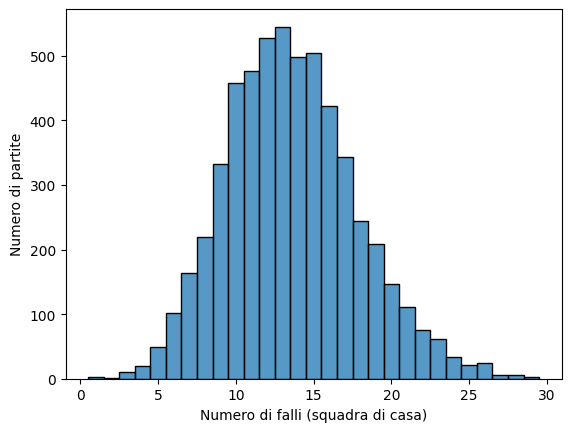

In [6]:
sns.histplot(data=df_serie_a, x='HF', bins=13, discrete=True)
plt.xlabel('Numero di falli (squadra di casa)')
plt.ylabel('Numero di partite')


L'asse $x$ dell'istogramma rappresenta il numero di falli fischiati, l'asse $y$ il numero di partite dove quel numero di falli e' stato registrato. L'istogramma dei dati ci dice, ad esempio, che in oltre 500 partite, il numero di falli fischiati alla squadra di casa e' stato di 13. Se andiamo a contare il numero di partite in cui sono stati fischiati 5 falli, approssimativamente abbiamo meno di 50 partite; partite nelle quali sono stati fischiati 25 falli sono ancora piu' rare, dal grafico direi che siamo nell'ordine di una ventina. L'istogramma ci visualizza la distribuzione dei dati (ci sono delle ragioni per le quali la forma della distribuzione ci sembra familiare e alcune di queste ragioni sono il motivo per il quale il calcio e' cosi' seguito e amato. Dettagli in seguito), ma poco ci dice su quali siano gli outlier, ossia i valori che si discostano significativamente dal comportamento centrale dei dati, secondo la definizione che abbiamo dato prima. Il box-plot lo visualizza meglio: 

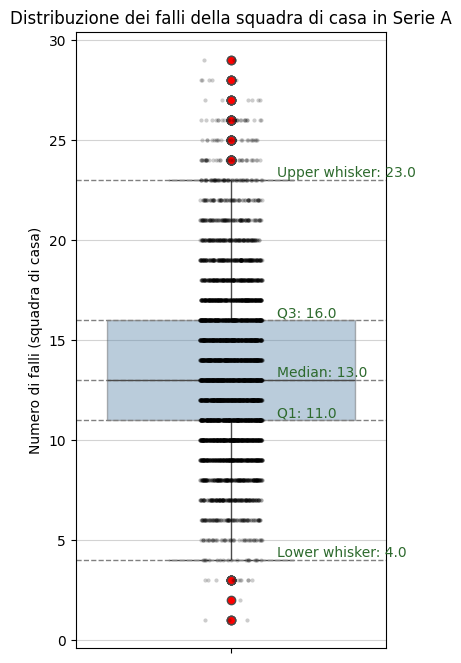

In [7]:
col = 'HF'

q1 = df_serie_a[col].quantile(0.25)
q3 = df_serie_a[col].quantile(0.75)
iqr = q3 - q1
median = df_serie_a[col].median()
lower_whisker = df_serie_a[col][df_serie_a[col] >= q1 - 1.5 * iqr].min()
upper_whisker = df_serie_a[col][df_serie_a[col] <= q3 + 1.5 * iqr].max()

fig, ax = plt.subplots(figsize=(4, 8))

ax.yaxis.grid(True, color='lightgrey', zorder=0)
ax.set_axisbelow(True)

sns.boxplot(
    data=df_serie_a,
    y=col,
    color = 'steelblue',
#    saturation=0.4,
    flierprops=dict(marker='o', color='red', markerfacecolor='red', markersize=6),
    ax=ax
)

for patch in ax.patches:
    patch.set_alpha(0.4)

sns.stripplot(
    data=df_serie_a,
    y=col,
    color='black',
    size=3,
    alpha=0.2,
    ax=ax
)

line_props = dict(color='grey', linestyle='--', linewidth=1)
labels = [
    (lower_whisker, f'Lower whisker: {lower_whisker:.1f}'),
    (q1,            f'Q1: {q1:.1f}'),
    (median,        f'Median: {median:.1f}'),
    (q3,            f'Q3: {q3:.1f}'),
    (upper_whisker, f'Upper whisker: {upper_whisker:.1f}'),
]

for val, label in labels:
    ax.axhline(val, **line_props)
    ax.text(0.65, val, label, transform=ax.get_yaxis_transform(),
            fontsize=10, color='#2d6a2d', va='bottom')


ax.set_title('Distribuzione dei falli della squadra di casa in Serie A')
ax.set_ylabel('Numero di falli (squadra di casa)');


Il box-plot ci visualizza intuitivamente alcuni dei concetti che ho introdotto precedentemente. Q1 e Q3 sono il primo e terzo quartile, e in blu e' visualizzata la parte di dati contenuta tra queste due fette. I whisker inferiore e superiore sono quelli ottenuti moltiplicando 1.5 volte la differenza e, in parole povere, ci dicono dove la stragrande maggioranza di dati si trova. In rosso sono evidenziati, appunto, gli outlier di questa distribuzione. Ci dicono che al di sotto di 4 falli e al di sopra di 23 falli si sono registrati gli "eventi eccezionali", ossia che si discostano di molto da quello che e' il comportamento generale sul numero di falli.

In [8]:
outliers_hf, list_outliers = get_outliers(df_serie_a,
             'HF')

print(f" Numero di outlier: {outliers_hf.shape[0]}, rappresentano il {outliers_hf.shape[0] / df_serie_a.shape[0] * 100:.2f}% del totale.")

 Numero di outlier: 109, rappresentano il 1.94% del totale.


Quindi su oltre 5000 partite, 109 rappresentano dei dati anomali (spesso il concetto di outlier e anomalie viene usato in maniera interscambiabile). E in effetti, a volte questi dati anomali possono nascondere dei problemi. Studiando proprio il numero di falli commesso in una partita, mi sono imbattuto su quattro partite in cui non era stato fischiato nemmeno un fallo a una delle due squadre. Le partite sono:

- [Chelsea - West Ham](https://www.espn.co.uk/football/matchstats/_/gameId/541714)
- [Wolves - Brighton](https://www.espn.co.uk/football/matchstats/_/gameId/513490)
- [Malaga - Real Sociedad](https://www.espn.co.uk/football/matchstats/_/gameId/490376) 
- [Lille - Rennes](https://www.espn.com/soccer/matchstats/_/gameId/609158) 

Andando a controllare sul sito di espn, ho effettivamente riscontrato che nelle prime 3 partite, una delle due squadre non aveva commesso neanche un fallo (o meglio, non era stato fischiato o registrato alcun fallo). Nella partita Malaga-Real Sociedad, inoltre, la squadra ospite non aveva commesso nessun fallo e aveva anche ricevuto un cartellino giallo (per perdita di tempo). Solo Lille-Rennes ha evidenziato un errore nei dati riportati dal sito football-data.co.uk laddove espn riporta un numero di falli superiore. 

Quindi lo studio degli outlier ha evidenziato che avere partite nelle quali non si fischiano falli a una delle due squadre sia possibile. Improbabile, ma possibile. E anche ha evidenziato un errore nella rilevazione dei dati.

Volendo riassumere, possiamo definire gli outlier come anomalie, dati che si discostano di parecchio da quello che e' il comportamento degli altri dati. Non sempre sono errori nella rilevazione, e, anzi, sono spesso casi rarissimi ma reali. Voglio precisare che, comunque, il "parecchio" e' qualcosa che decidiamo noi una volta che usiamo il metodo per rilevare gli outlier, che puo' cambiare a seconda della distribuzione e dal tipo di analisi che vogliamo condurre. Il numero di outlier dipende da come sono distribuiti i dati: nel caso del numero di falli, abbiamo trovato 109 outlier su oltre 5000 partite, circa il 2%. In altre distribuzioni la percentuale cambia, ma rimane sempre una frazione piccola del totale (altrimenti non sarebbero outlier).

## Falli e cartellini

L'affermazione che vogliamo studiare parla di falli commessi e cartellini gialli ricevuti. Dal punto di vista colloquiale, nella cornice di un intervista a una testata calcistica, o nel gergo del bar dello sport, l'affermazione e' chiara e cristallina: una squadra commette un tot numero di falli e riceve un certo numero di cartellini gialli o rossi. Anche se la maggior parte di noi dormiva durante le lezioni di matematica a scuola, abbiamo tutti in mente che queste due quantita', falli e cartellini, sono correlate nel senso che piu' commetto falli e piu' mi aspetto che cresca il numero di cartellini. La nostra mente pragmatica e il buon senso, ci dice anche che se guardiamo nel lungo periodo, ossia senza fermarci alla singola partita ma prendendone tante, e le condizioni sono uguali per tutti (specie gli arbitraggi), allora bene o male il numero di cartellini ricevuti sara' proporzionale al numero di falli commessi e questa proporzione, sempre nell'ottica di un arbitraggio neutrale, deve essere bene o male uguale per tutti. Il nostro buonsenso, la nostra intuizione, ci porta anche a dire che possiamo accettare che la proporzione non sia uguale per tutti ma che possano esserci degli scostamenti tra una squadra e un'altra, del resto anche quando ordiniamo due etti di prosciutto dal salumiere non ci aspettiamo che siano perfettamente 200 grammi e siamo disposti a pagare la differenza - esistono teoremi matematici che dimostrano che le mani dei salumieri hanno una taratura del peso nettamente diversa dagli strumenti che misurano e il peso che loro valutano e' sempre sottostimato rispetto a quello riportato dalla bilancia. Solo che una volta che hai affettato 300 grammi, che fai, li rimetti indietro?. Eppure il nostro buonsenso ci porta a fare delle ipotesi matematiche che, anche se non ce ne accorgiamo, sono ben lontane dall'essere dei principi universali e, anzi, proprio in linea di principio dal punto di vista matematico e fisico queste ipotesi proprio non sussistono. 

In primo luogo, un fallo commesso e' gia' diverso da fallo fischiato. Non tutti i falli commessi vengono fischiati, sia perche' nel calcio c'e' la regola del vantaggio, sia perche' non tutti i falli vengono visti e sanzionati dall'arbitro ("sanzionato dall'arbitro" e' una frase automatica di ognuno di noi che segue il calcio, e vuole scrivere un articolo, prima o poi la scrive. E' come il verbale dei carabinieri pieno di locuzioni proprie quali "mi apprestavo ad avvicinarmi al luogo preposto all'imbarco del servizio di mobilita' cittadina" invece di scrivere "stavo per prendere l'autobus").

Sulla correlazione tra cartellini gialli e falli commessi, un primo aspetto che gia' non stiamo includendo e' il fatto che un cartellino giallo possa essere dato da un arbitro senza che sia stato fischiato un fallo. Ad esempio, quando si commina (altro termine proprio dei cartellini gialli) un cartellino per proteste o per perdite di tempo, potrebbe essere stato addirittura fischiato in precedenza un fallo a favore.

Ma un aspetto ancora piu' sofisticato, e' il fatto che, inconsciamente, trattiamo i falli commessi e i cartellini comminati come eventi a se indipendenti, ossia che due falli consecutivi o due ammonizioni consecutive siano eventi statisticamente indipendenti gli uni dagli altri. E questa e' una bella ipotesi, forte, che andrebbe se non altro dimostrata.  

Senza fare ulteriori precisazioni, il senso di questo sproloquio e' che quando poi vogliamo eseguire un'indagine statistica seria su falli e cartellini, tutte devono avere un corrispettivo matematico per quanto riguarda i modelli statistici e i test di ipotesi che vogliamo utilizzare. 

Torniamo un attimo a quanto dichiarato nell'intervista e partiamo dalle cose semplici e ci chiediamo quanti falli sono stati fischiati nel campionato italiano di quest'anno e come sono distribuiti.

### Partiamo dalle basi: i falli

Partiamo da una domanda semplice: quanti falli si fischiano in una tipica partita di serie A? 

Ogni partita e' diversa dalle altre, le squadre che si affrontano hanno motivazioni che dipendono da quella singola partita e che sono diverse a seconda della loro forza, la posizione in classifica, se giocano in casa o in trasferta, insomma, tutti fattori che rendono le partite di quella giornata e di tutte le altre giornate indipententi le une dalle altre: ognuna e' particolare, ognuna e diversa dall'altra. Ovviamente, ci sono fattori che possono influenzare il modo in cui due squadre che giocano una partita che dipendono da altre partite: il risultato di una concorrente puo' influenzare la tattica e le motivazioni, quindi una totale indipendenza non c'e'.

Fatta questa ovvia premessa, nel campionato italiano 2024/25, quanti falli sono stati fischiati in ogni partita? A partire dai dati sulle singole partite che abbiamo, andiamo a costruirci l'istogramma dei falli fischiati per ogni partita, ossia contiamo il numero di falli fischiati per ogni partita e vediamo in quante partite sono state commessi 30 falli, quante 35 e cosi' via.  

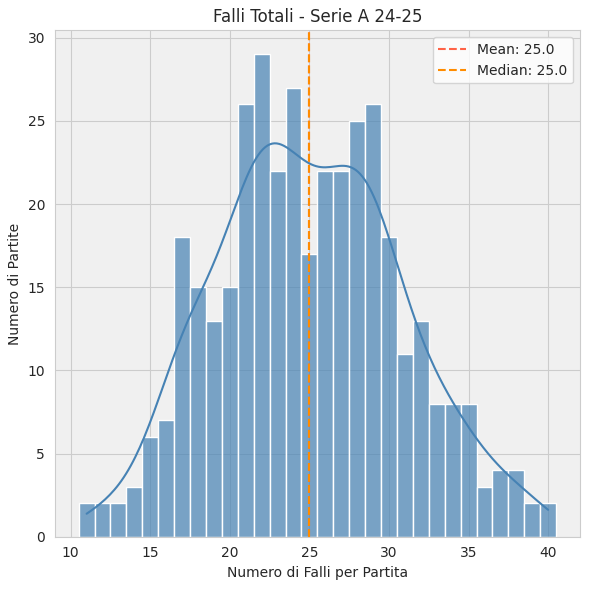

In [9]:
# Plot Serie A total fouls distribution
fig, ax = plot_distribution(all_matches_serie_a_2425, 
                            'total_fouls',
                            title = 'Falli Totali - Serie A 24-25',
                            figsize=(6,6),
                            xlabel = 'Numero di Falli per Partita',
                            ylabel= 'Numero di Partite',
                            discrete=True)

In [10]:
all_matches_serie_a_2425['total_fouls'].describe()

count    380.000000
mean      25.002632
std        5.793500
min       11.000000
25%       21.000000
50%       25.000000
75%       29.000000
max       40.000000
Name: total_fouls, dtype: float64

L'istogramma che risulta dai dati assomiglia a quella che si chiama una distribuzione normale: la maggior parte delle partite hanno un numero di partite che varia tra i 20 e i 30 falli e i dati sembrano abbastanza simmetrici: a destra e a sinistra della media, il numero di partite con piu' o meno falli e' piu' o meno lo stesso. Volendo essere ancora piu' analitici, sembra quasi che ci siano due distribuzioni, con due picchi a sinistra e a destra della media, che si fondono assieme. 

### Il modello e la realta'. 

Quando, in statistica come in fisica, di un modello, parliamo sempre di un'approssimazione della realta'. Quando dico che la distribuzione assomiglia a una "distribuzione normale", la sto approssimando a un modello che e', esso stesso, un'approssimazione della realta'. Quanto buona sia questa approssimazione, tanto piu' posso trarre delle conclusioni sui dati ragionevoli ed entro un determinato margine di errore. Dal punto di vista statistico, vista la distribuzione dei dati, posso supporre che se li modello come una distribuzione normale l'errore non sara' enorme.

Faccio un esempio pratico. Nella stagione 2024/25 la media per partita del numero di falli fischiati e' stata di circa 25 con una deviazione standard, ossia il discostamento dalla media di quasi 6 falli. In termini pratici, diremmo che in ogni partita sono stati fischiati 25 falli piu' o meno 6. Media e deviazione standard li ho ricavati dai dati reali, empirici. A questo punto, dico che i dati si distribuiscono come una Gaussiana (o Normale) con valore medio di 25 e deviazione standard di 6. Se interrogo il modello cosi' costruito, senza andare a contare i dati reali, saro' in grado di fare previsioni. Ad esempio, posso chiedermi quale sia la probabilita' che, in una partita ipotetica, l'arbitro fischi piu' di 30 falli. Se uso il modello gaussiano, la risposta sara' di: 

In [11]:
from scipy import stats

p = 1 - stats.norm.cdf(30, 
                       loc=all_matches_serie_a_2425['total_fouls'].mean(), 
                       scale=all_matches_serie_a_2425['total_fouls'].std())
print(f"P(X >= 30) = {p:.4f}")

P(X >= 30) = 0.1942


Il modello ci dice che questa probabilita' e' di circa il 20%. Se ora andiamo a contare sulle 380 partite, quante ce ne sono state con 30 o piu' falli e ne calcoliamo la frazione otterremo: 

In [12]:
n_fouls = 30
total_matches = all_matches_serie_a_2425.shape[0]
n_matches = all_matches_serie_a_2425[all_matches_serie_a_2425['total_fouls'] >=n_fouls].shape[0]
print(f"Numero di partite con almeno 30 falli: {n_matches}")
print(f"Frazione di partite con almeno 30 falli: {n_matches/total_matches:.4f}")

Numero di partite con almeno 30 falli: 81
Frazione di partite con almeno 30 falli: 0.2132


Il modello dice che la probabilita' e' di circa il 20%, la realta' mi dice che la frazione di partite con 30 o piu' falli rispetto al totale e' di poco piu' del 21%, meno del 2% di errore tra valore ottenuto con il modello rispetto al dato realte. Sta a noi decidere se questo margine di errore sia accettabile o meno, e dipende dal tipo di analisi o di precisione che vogliamo ottenere. Possiamo migliorare il modello e ottenere risultati piu' precisi, ma ogni volta che miglioriamo un modello, e quello normale e' tra i piu' semplici, andiamo a pagare un costo che puo' essere in termini di complessita' di calcolo, di interpretabilita, di quanto tempo ci metto a calcolare tutto. Alla fine della fiera, se modelliamo i dati del numero di falli fischiati come un modello normale, non ci allontaniamo di molto dalla realta' e possiamo anche rispondere a domande interessanti fidandoci delle risposte del modello probabilistico. 

Ad esempio, se volessimo confrontare il numero di falli fischiati in Serie A nel campionato di calcio 2024/25 con quelli del campionato Inglese nella stessa stagione, possiamo dire qualcosa sulla loro differenza? Senza andare troppo per il sottile, andiamo subito a vedere come sono distribuiti i dati sui falli fischiati in Premier League per partita.

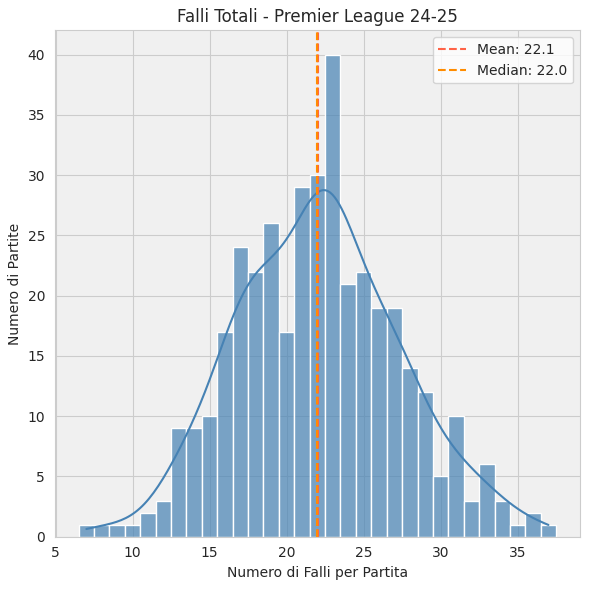

In [13]:
# Plot Premier League total fouls distribution
fig, ax = plot_distribution(all_matches_premier_league_2425, 
                            'total_fouls',
                            title = 'Falli Totali - Premier League 24-25',
                            figsize=(6,6),
                            xlabel = 'Numero di Falli per Partita',
                            ylabel= 'Numero di Partite',
                            discrete=True)

In [14]:
all_matches_premier_league_2425['total_fouls'].describe()

count    380.000000
mean      22.065789
std        5.271358
min        7.000000
25%       18.000000
50%       22.000000
75%       25.250000
max       37.000000
Name: total_fouls, dtype: float64

Due campionati diversi, la stessa forma per la distribuzione ma media e mediana diverse: nel campionato italiano la media e' di circa 25 falli fischiati a partita, nel campionato inglese circa 22 (con una deviazione standard di circa piu' o meno cinque falli a partita). Questa differenza e' "statisticamente significativa"? Quando sin parla di differenza "statisticamente significativa", facciamo riferimento al fatto che, come abbiamo visto, i valori medi che descrivono una misura hanno un margine di errore che possiamo attribuire al caso. Come abbiamo detto all'inizio, ogni partita e' un caso a se stante, ci sono tantissime variabili in gioco e il risultato di una misura e' dettato molto dal caso e quindi si discostera' dal suo valore medio. Nel caso dei campionati italiano e inglese, le medie sono diverse e anche gli errori sono diversi. Se andiamo a visualizzare le due curve, ci saranno molte sovrapposizioni e quindi e' ragionevole chiedersi se la differenza che vediamo nei valori medi e' possibile attribuirla al caso, all'errore che entrambe le misure si portano dietro, o c'e' effettivamente una differenza strutturale che non dipende dall'aleatorieta' delle partite? Per questo, ci si serve di test statistici, e i test statistici dipendono da come modelliamo le distribuzioni.

Se ora ipotizziamo che entrambe le distribuzioni dei dati sia normale, ci sono test statistici che ci permettono di dire, appunto, se le medie sono effettivamente diverse. I piu' famosi sono i t-test di [Student](https://en.wikipedia.org/wiki/Student%27s_t-test) e [Welch](https://en.wikipedia.org/wiki/Welch%27s_t-test). Il test di Student parte dal presupposto che le due misure (popolazioni) che stiamo confrontando siano distribuite normalmente (ossia gaussianamente) e abbiano uguale varianza. Il test di Welch considera il fatto che le due distribuzioni siano ancora normali, ma abbiano diversa varianza. 

E a questo punto parte il momento Barbero.

Se pensate che la probabilita' e la statistica siano nate, come discipline scientifiche, dalla mente di brillanti matematici che cercavano di dimostrare l'esistenza di dio facendone una questione di interrogare il caso, confrontarle con l'esperienza fisica e tirar fuori modelli complessi che potessero parlare dell'oltre uranio, avete in parte ragione. Una parte molto piccola. Il calcolo della probabilita' nasce con [Gerolamo Cardano](https://en.wikipedia.org/wiki/Gerolamo_Cardano), un astrologo e giocatore d'azzardo, e con due tra le piu' brillanti menti matematiche di ogni tempo: [Pierre de Fermat](https://en.wikipedia.org/wiki/Pierre_de_Fermat) e [Blaise Pascal](https://en.wikipedia.org/wiki/Blaise_Pascal). A Cardano si deve il primo libro che parla dei giochi basati sul caso (il Liber de ludo aleae), nel quale descrive i giochi cercando di spiegarli (e capirli) in termini di quale sia la probabilita' di vincere ai giochi. Ah, anche barando. Cardano, nel libro, spiega anche i trucchi per barare. E se vi chiedete se questo brillante matematico fosse poi in grado di vincere, sappiate che Cardano, per tutta la sua vita, lotto' contro debiti e cambiali a causa del suo modo di giocare. E se, come me, avete un senso dell'umorismo discutibile, troverete divertente anche la storia dei suoi figli. Per quanto riguarda Fermat e Pascal, dovrebbe anche essere inutile sottolineare il contributo che hanno dato al progresso scientifico. Entrambi vissuti nel '600, il loro contributo e' ancora oggi usato in ambito scientifico e le loro teorie vengono usate in campi come la matematica, la fisica, l'economia e tante applicazioni pratiche anche oggi all'avanguardia. Due che non perdevano tempo a vedere serie su Netflix, insomma. Pascal ancora oggi e' visto come un pensatore influente in ambito religioso. E quindi, quando corrispondeva con Fermat e assieme costruivano le fondamenta del calcolo probabilistico, di cosa parlavano? Parlavano di gioco d'azzardo. Di quale fosse il modo corretto di valutare le scommesse e di come si potesse capire se si potesse avere un vantaggio statistico nei giochi d'azzardo (ringraziamo anche il  per questo). Tra parentesi, gli stessi principi che Pascal trasse dalla corrispondenza con Fermat, li uso' per provare l'esistenza di dio. E se vi chiedete se alla fine del loro carteggio, avessero trovato la soluzione per vincere al gioco d'azzardo, la risposta la da la vita del [Cavaliere de Mere](https://en.wikipedia.org/wiki/Antoine_Gombaud, ossia quello che aveva consultato i due scienziati per avere la risposta. La risposta e' no. 

Questo per quanto riguarda le origini del calcolo della probabilita', e allora i test di ipotesi per cosa nascono? Questo famoso t-test di Student per capire se la media di due popolazione e' statisticamente la stessa o diversa, per cosa nasce? Dalla birra. La Guinness, per essere precisi. Il test di Student e' stato sviluppato da [William Sealy Gosset](https://en.wikipedia.org/wiki/William_Sealy_Gosset), uno statistico e chimico che lavorava, appunto, per la Guinness e il cui lavoro era controllare la qualita' della birra. Il test si chiama di Student perche' quando Gosset pubblico' l'articolo che lo descriveva, non poteva usare il suo nome dato che lavorava per un privato che si preoccupava di non far conoscere i loro segreti industriali in giro. Gosset, allora, si firmo' per quello che era in quel momento: uno studente e da li il test di Student. E se credete mi sia inventato questa storia, no e' tutto vero. Quindi, i test statistici che oggi vengono usati per testare medicine, vaccini e tante altre cose, sono nati per migliorare la produzione di birra. 

Birra e gioco d'azzardo. Se non riuscite ad appassionarvi a un tema che parte da queste premesse, non so cosa possa appassionarvi.

Finito il nostro momento Barbero, torniamo all'applicazione del test nel nostro caso (siamo passati dalla birra al calcio e quindi la continuita' narrativa e' assicurata). Vogliamo sapere se le due medie siano diverse, ma dal punto statistico partiamo invece dal chiederci quale sia la probabilita' che le due medie siano uguali: e' la famosa Ipotesi Zero, Ipotesi Nulla, Null Hypothesis chiamiamola come vogliamo noi, quella e'. I test statistici funzionano bene o male tutti cosi. Si sceglie innanzi tutto una soglia di significanza statistica detta $\alpha$. Si confrontano poi le due medie e i loro rispettivi errori statistici e ci si chiede, sotto l'ipotesi che le due medie siano uguali, qual e' la probabilita' di osservare uno scostamento tra le medie cosi' estremo da quello registrato? Detto in altre parole, se partiamo dal presupposto che le medie sono uguali, qual'e' la probabilita' di osservare poi con i dati una differenza cosi' grande? Questa probabilita' si chiama p-value. A questo punto si confronta il p-value con la soglia di significanza statistica e:

- se il p-value e' maggiore della soglia $\alpha$, allora non c'e' significanza statistica e non riesco a scartare l'ipotesi che le due medie siano le stesse ma differiscano solo "per caso"
- se il p-value e' minore della soglia, allora il fatto che le due medie siano le stesse e la differenza sia solo un caso diventa difficile da sostenere e allora mi devo cercare un'ipotesi alternativa a quella che mi dice che le medie sono uguali

Ho tralasciato, in questa spiegazione, parecchie sottigliezze matematico-filosofico (che in effetti sottigliezze non sono) e mi sono tenuto lontano dal gergo tecnico e gia' molte cose sembrano complicate senza spiegazione. Ad esempio, perche' scegliere una soglia $\alpha$ e non andare direttamente a guardare il p-value e vedere quanto e'? Perche' la fatica di definire l'ipotesi zero in quel modo e non andare direttamente a vedere quanto siano diversi? Perche' non definire il p-value come la probabilita' dei dati e invece definirlo come la probabilita' di osservare una differenza cosi' estrema? Queste che sembrerebbero sottigliezze, non lo sono  
ma sarebbe troppo lungo approfondirle in questo notebook, e gia' mi rendo conto che sto scrivendo troppo.

Finalmente, vediamo se in Inghilterra e in Italia si fischiano piu' o meno falli. Iniziamo con Student.

In [15]:
serie_a_2425_fouls = all_matches_serie_a_2425['total_fouls']
premier_league_2425_fouls = all_matches_premier_league_2425['total_fouls']

t = compare_two_groups(serie_a_2425_fouls, 
                   premier_league_2425_fouls,
                   label_a='Serie A 24-25',
                   label_b='Premier League 24-25')

In [16]:
t.show('student_t')

Serie A 24-25 vs Premier League 24-25
--------------------------------------------------
  mean_Serie A 24-25        25.0026
  mean_Premier League 24-25 22.0658
  std_Serie A 24-25         5.7935
  std_Premier League 24-25  5.2714
  n_Serie A 24-25           380
  n_Premier League 24-25    380
  mean_diff                 +2.9368
--------------------------------------------------
  student_t                 stat=7.3090, p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  0.5303
  rank_biserial             -0.2846


Il test di Student mi dice che il p-value e' di 0.000 etc etc. ben al di sotto della soglia del 5% (o $\alpha = 0.05$). Quindi, se eseguiamo il test supponendo le distribuizioni dei falli fischiati in Inghilterra e in Italia come normali e con uguale varianza, la differenza tra le medie e' statisticamente significativa: non e' dovuta a fluttuazioni statistiche ma e' sistematica.

E se consideriamo il fatto che la varianza nelle medie italiane e inglesi e' diversa? Allora ci aiuta il test di Welch:

In [17]:
t.show('welch_t')

Serie A 24-25 vs Premier League 24-25
--------------------------------------------------
  mean_Serie A 24-25        25.0026
  mean_Premier League 24-25 22.0658
  std_Serie A 24-25         5.7935
  std_Premier League 24-25  5.2714
  n_Serie A 24-25           380
  n_Premier League 24-25    380
  mean_diff                 +2.9368
--------------------------------------------------
  welch_t                   stat=7.3090, p=0.0000  (Sig.)
--------------------------------------------------
  cohens_d                  0.5303
  rank_biserial             -0.2846


La situazione non cambia: il valore del p-value e' ancora 0 (a non so quante cifre significative). Arrendiamoci e, sotto l'ipotesi di normalita' dei dati, possiamo tranquillamente affermare che in Premier League si fischiano meno falli per partita che in Serie A. E quindi arbitrare all'Inglese non e' una frase fatta ma ha, almeno per quanto riguarda il numero di falli, un fondamento statistico.